In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import fmatoolbox as fma
import ISRUtilities as isru
import xarray as xr
import pathlib
froot = pathlib.Path().cwd().parent.parent.parent / 'Results/Figures/UnitEntrainment'
batch_file = '/mnt/hubel-data-103/Pietro/InfraSlowNRPaper/Data/IS_intervals.batch'
do_save = False

In [50]:
def _regISAFiring(session,regs=None,when='sleep.*#0',n_points=15):

    R = fma.regions.regions(session,phases=when,events='InfraSlowRhythm/infraslowaval')
    regs = R.ids if regs is None else np.array(regs)[np.isin(regs,R.ids)]
    isa = R.eventIntervals('slownr')
    on = R.eventIntervals('slowavalnr')
    if on.size == 0:
        return None, None
    _, off = isru.ISCycles(isa,on,return_off=True)
    on = on[(np.diff(on)>3).ravel() ,:]
    off = off[(np.diff(off)>5).ravel() ,:]

    on_t = []
    for o in on:
        on_t.append(np.linspace(o[0],o[1],n_points))
    on_t = np.concatenate(on_t)
    off_t = []
    for o in off:
        off_t.append(np.linspace(o[0],o[1],n_points))
    off_t = np.concatenate(off_t)

    fr = R.firingRate(regs=regs,norm=True)
    fr_on = []
    fr_off = []
    for i, reg in enumerate(regs):
        d = np.interp(on_t, fr[:,0], fr[:,i+1])
        fr_on.append(d.reshape(-1,n_points))
        d = np.interp(off_t, fr[:,0], fr[:,i+1])
        fr_off.append(d.reshape(-1,n_points))

    fr_on = xr.DataArray(fr_on,dims=['reg','interval','phi'],coords={'reg': regs, 'phi': np.linspace(0,np.pi,n_points), 'rat': int(R.rat)})
    fr_off = xr.DataArray(fr_off,dims=['reg','interval','phi'],coords={'reg': regs, 'phi': np.linspace(np.pi,2*np.pi,n_points), 'rat': int(R.rat)})

    return fr_on, fr_off

In [51]:
session = fma.data.readBatchFile(batch_file)[0][15]
print(session)
fr_on, fr_off = _regISAFiring(session)

/mnt/hubel-data-139/karadoc/Rat004_20240227/Rat004_20240227.xml


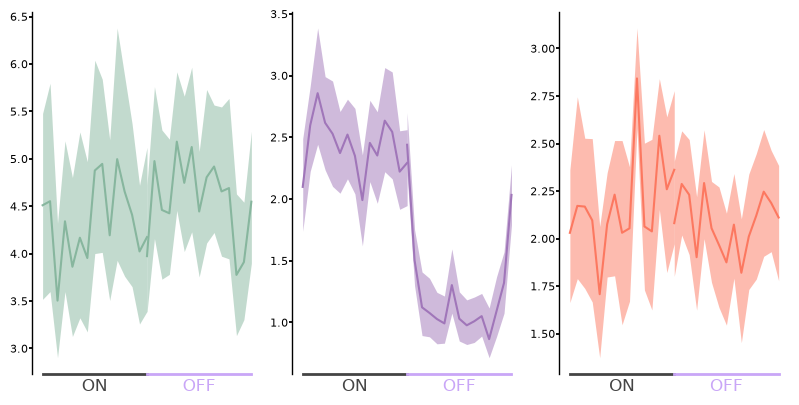

In [52]:
fig, ax = fma.plotting.makeFigure(n=(1,3))
for i, reg in enumerate(fr_on.reg.values):
    fma.plotting.semPlot(fr_on.phi,fr_on.sel(reg=reg),ax=ax[i],color=isru.paperColors(reg))
    fma.plotting.semPlot(fr_off.phi,fr_off.sel(reg=reg),ax=ax[i],color=isru.paperColors(reg))
isru.ISAxes(ax)

run batch

In [53]:
fr_on, fr_off = fma.data.runBatch(batch_file,_regISAFiring,parallel=True)
fr_on_cat = xr.concat([d.mean(dim='interval') for d in fr_on if d is not None],dim='rat',join='outer')
fr_on_avg = fr_on_cat.groupby('rat').mean(dim='rat',skipna=True)
fr_off_cat = xr.concat([d.mean(dim='interval') for d in fr_off if d is not None],dim='rat',join='outer')
fr_off_avg = fr_off_cat.groupby('rat').mean(dim='rat',skipna=True)


Starting Batch, 2026-07-28 10:09:01.200259 

Batch completed with 0 errors, 2026-07-28 10:09:07.258703


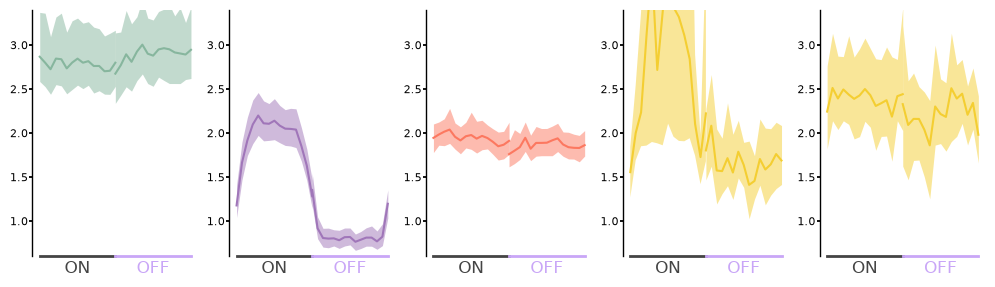

In [58]:
fig, ax = fma.plotting.makeFigure(size=(25,7),n=(1,5))
for i, reg in enumerate(fr_on_cat.reg.values):
    fma.plotting.semPlot(fr_on_cat.phi,fr_on_cat.sel(reg=reg),ax=ax[i],color=isru.paperColors(reg))
    fma.plotting.semPlot(fr_off_cat.phi,fr_off_cat.sel(reg=reg),ax=ax[i],color=isru.paperColors(reg))
isru.ISAxes(ax,ylim=(0.6,3.4))

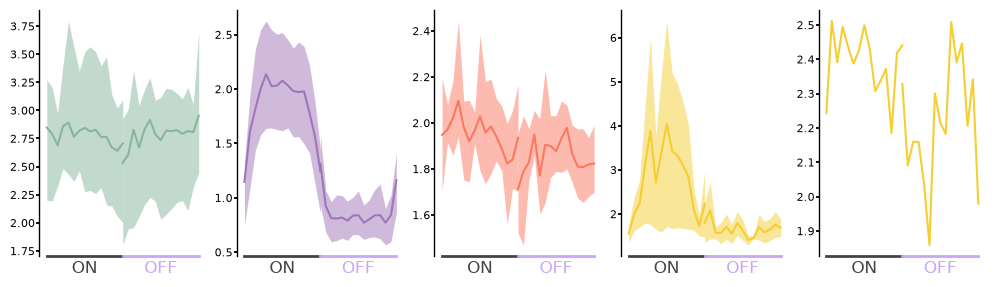

In [54]:
fig, ax = fma.plotting.makeFigure(size=(25,7),n=(1,5))
for i, reg in enumerate(fr_on_avg.reg.values):
    fma.plotting.semPlot(fr_on_avg.phi,fr_on_avg.sel(reg=reg),ax=ax[i],color=isru.paperColors(reg))
    fma.plotting.semPlot(fr_off_avg.phi,fr_off_avg.sel(reg=reg),ax=ax[i],color=isru.paperColors(reg))
isru.ISAxes(ax)

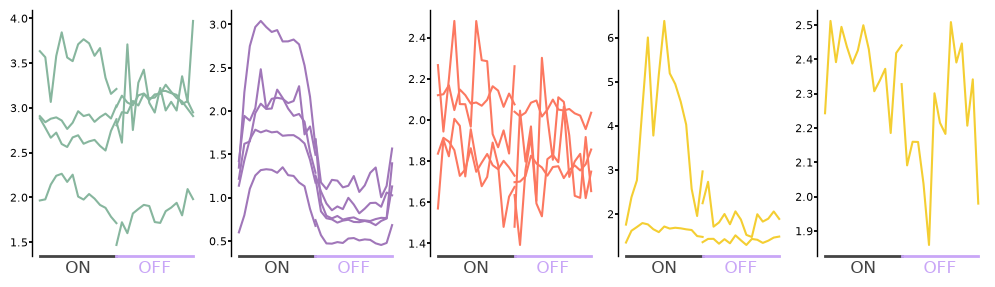

In [55]:
# see per animal
fig, ax = fma.plotting.makeFigure(size=(25,7),n=(1,5))
for j, rat in enumerate(fr_on_avg.rat.values):
    fon = fr_on_avg.sel(rat=rat)
    foff = fr_off_avg.sel(rat=rat)
    for i, reg in enumerate(fon.reg.values):
        fma.plotting.semPlot(fon.phi,fon.sel(reg=reg),ax=ax[i],color=isru.paperColors(reg))
        fma.plotting.semPlot(foff.phi,foff.sel(reg=reg),ax=ax[i],color=isru.paperColors(reg))
isru.ISAxes(ax)